# Predicting Diabetes Risk Using Machine Learning


---

## Project Overview

This project develops and evaluates machine learning models to predict diabetes risk from patient health data. The objective is not only to optimise predictive performance, but also to assess model interpretability, fairness across demographic groups, and practical considerations for deployment in a real-world setting.

## Dataset Overview


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


------------ Data Shape ------------
(768, 9) 

------------ Data Info ------------
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None 

------------ Data Head ------------
|    |   Pregnancies |   Glucose |   BloodPressure |   SkinThickness |   Insulin |   BMI |   DiabetesPedigreeFunction |   Ag

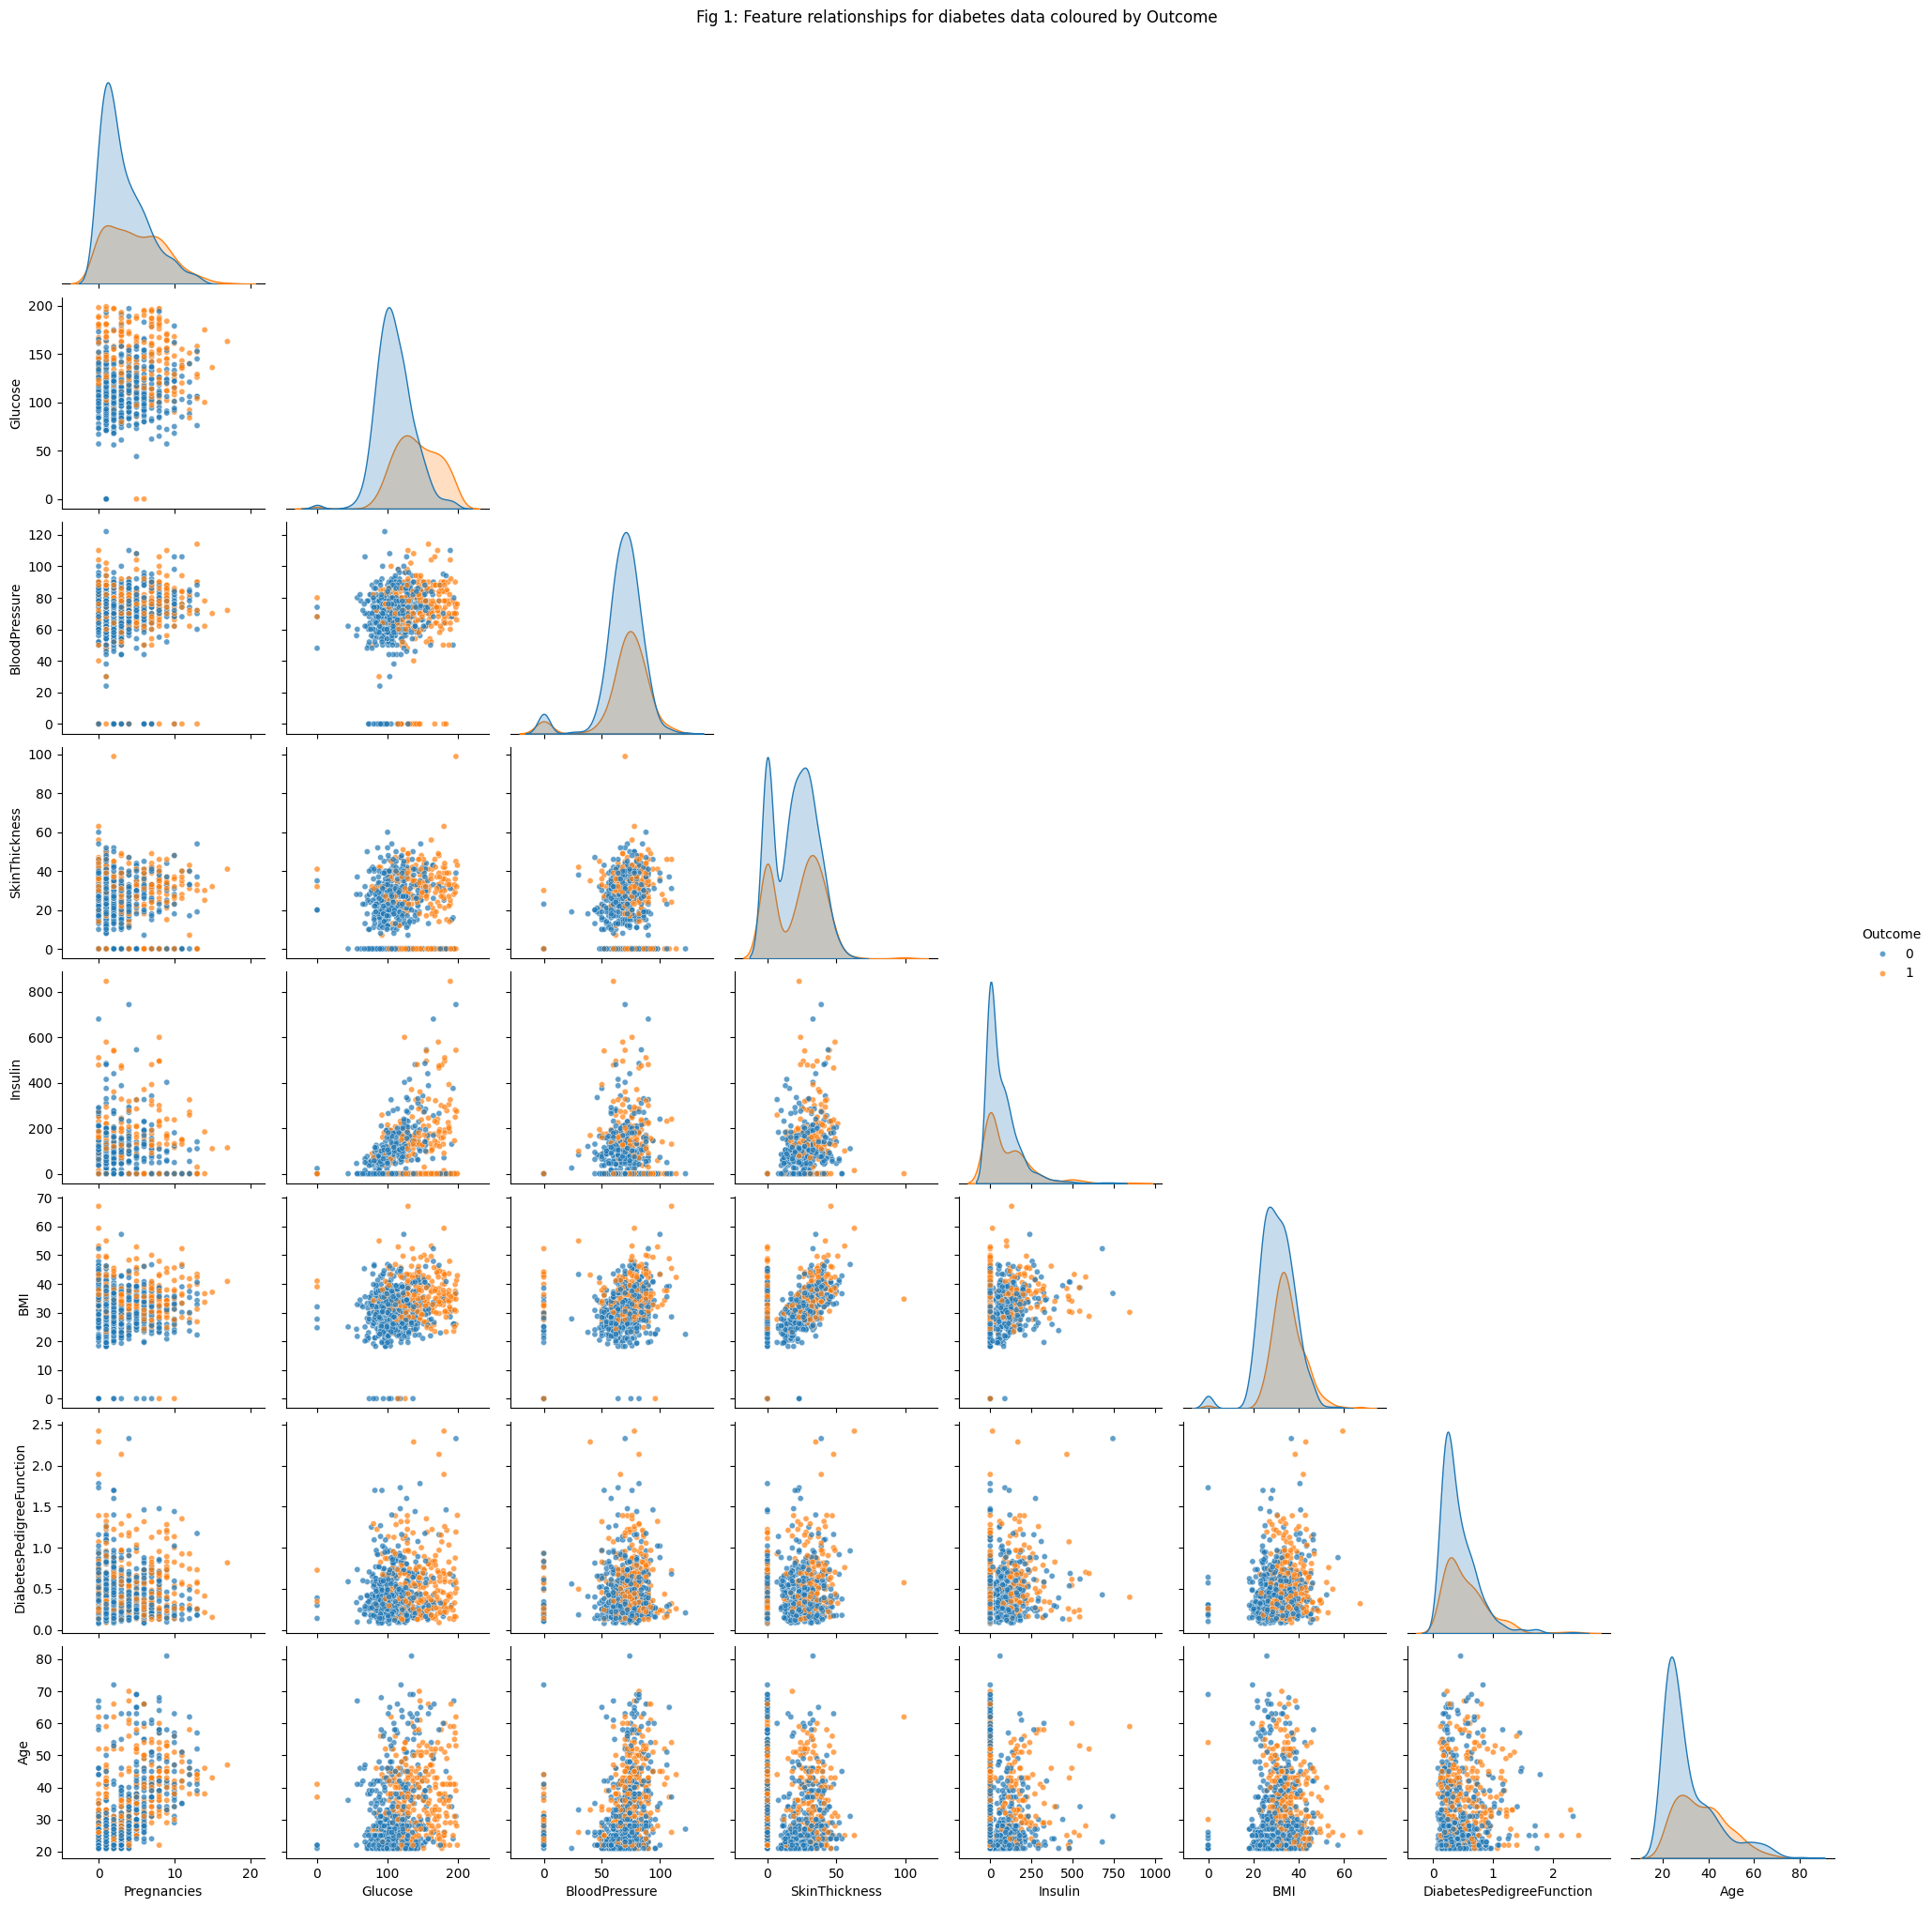

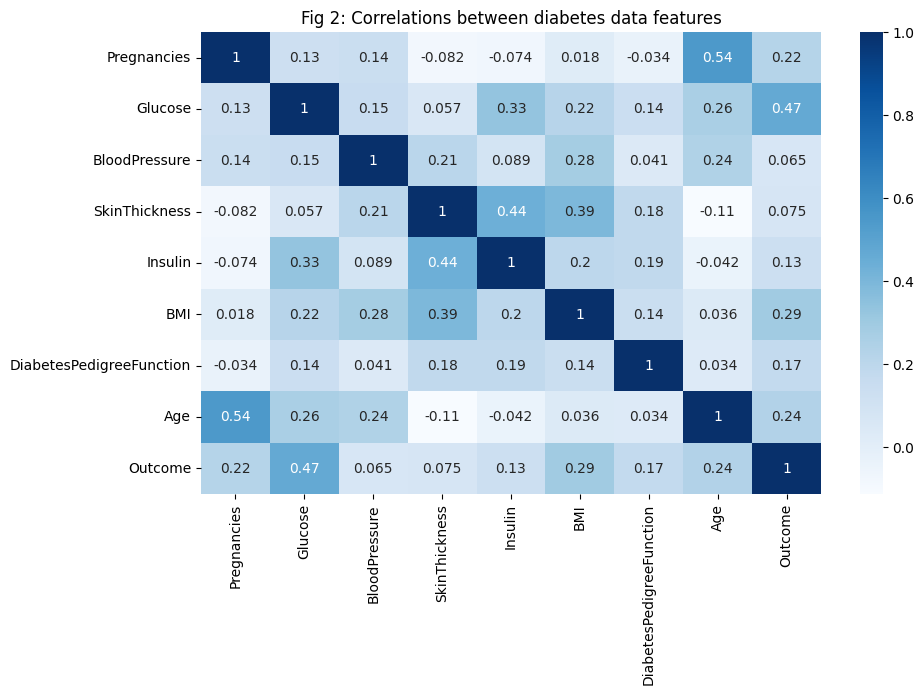

In [ ]:
#SET UP ALL MODULES AT THE OUTSET

# PIP INSTALL ANY NON-DEFAULT MODULES (NOTE THIS IS CODED TO WORK ON COLAB)
# THESE MAY REQUIRE TIME TO INSTALL AS THE NOTEBOOK RUNS
# Check if CatBoost is installed. If not, install it (quietly so as to not fill the output).
try:
  import catboost
except ModuleNotFoundError:
  !pip install catboost --quiet

# Check if eli5 is installed. If not, install it (quietly so as to not fill the output).
try:
  import eli5
except ModuleNotFoundError:
  !pip install eli5 --quiet

# Check if TabNet is installed. If not, install it (quietly so as to not fill the output).
try:
  from pytorch_tabnet.tab_model import TabNetClassifier
except ModuleNotFoundError:
  !pip install pytorch-tabnet --quiet
  
# Check if seaborn is installed. If not, install it (quietly so as to not fill the output).
try:
  import seaborn as sns
except ModuleNotFoundError:
  !pip install seaborn --quiet
  
# Check if statsmodels is installed. If not, install it (quietly so as to not fill the output).
try:
  from statsmodels.stats.outliers_influence import variance_inflation_factor
except ModuleNotFoundError:
  !pip install statsmodels --quiet

#IMPORT ALL REQUIRED MODULES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import numpy as np
import math
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier, Pool, metrics, cv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from eli5 import show_weights, show_prediction
from IPython.display import display
from sklearn.model_selection import GridSearchCV, KFold
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from sklearn.metrics import classification_report

# Configure a direct download link for the diabetes data held on my google shared folder
file_id='1c9viUvbiI3jnKBLsBhwIP6Ug1gxP0Z_t'
url = f'https://drive.google.com/uc?id={file_id}'

diabdata = pd.read_csv(url, sep=',')

# Investigate the data set for initial observations
# What does the data look like?
print('------------ Data Shape ------------')
print(diabdata.shape,'\n')
print('------------ Data Info ------------')
print(diabdata.info(),'\n')
print('------------ Data Head ------------')
print(tabulate(diabdata.head(), headers='keys', tablefmt='pipe'))
print('\n')

# Stats detail on the data
print('------------ Data Desription ------------')
print(tabulate(diabdata.describe().T.round(2),
               headers='keys', tablefmt='pipe'))
print('\n')

# Zero value entries
zero_features = ['Insulin', 'Glucose', 'BloodPressure', 'BMI', 'SkinThickness']
print('------------- Features with Zero Value Records and Quantities --------')
for feat in zero_features:
    print(f"{feat}: {(diabdata[feat] == 0).sum()}")

# Pairplot to easily see the relationships between features coloured by Outcome
g = sns.pairplot(
    data=diabdata,
    hue='Outcome',
    corner=True,
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 20}
)

g.fig.suptitle('Fig 1: Feature relationships for diabetes data coloured by Outcome', y=1.02)
plt.show()

print('\n')
# Show a heatmap of the correlation between features (Pearson's Correlation Coefficient)
plt.figure(figsize=(10,6))
sns.heatmap(diabdata.corr(numeric_only=True),annot=True,cmap='Blues')
plt.title('Fig 2: Correlations between diabetes data features')
plt.show()

The dataset contains 768 records and 9 variables, including the target variable `Outcome`. All features are numeric and represent patient health indicators such as glucose, BMI, age, and insulin. This makes the dataset suitable for supervised classification modelling.

## Data Quality, Distributions, and Preprocessing

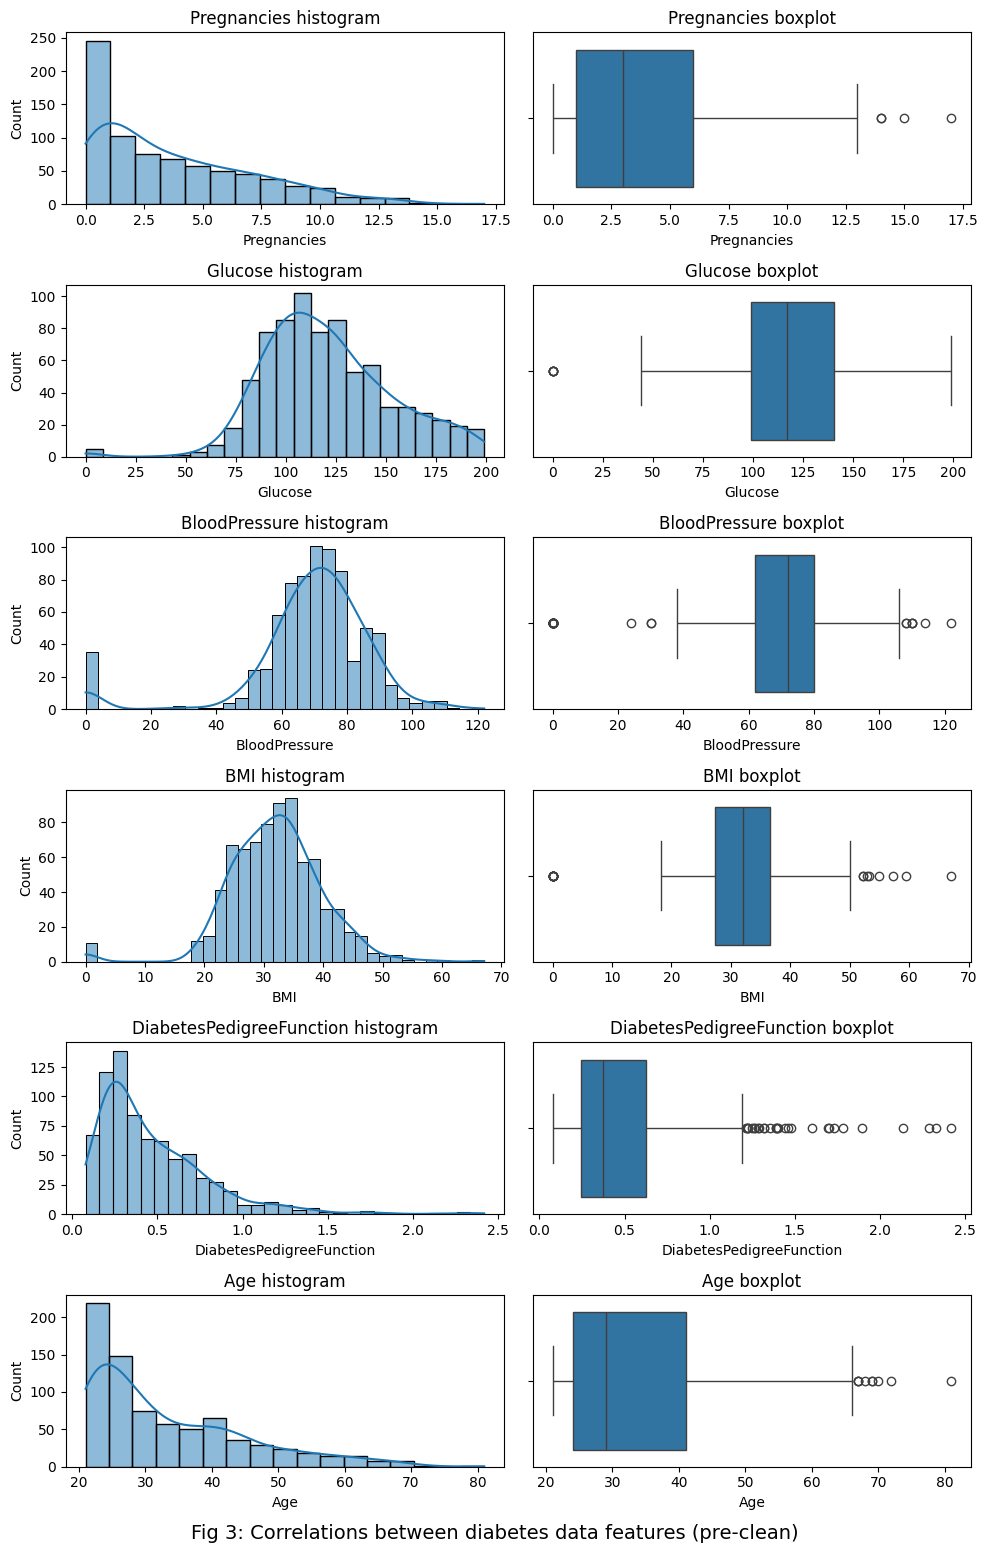

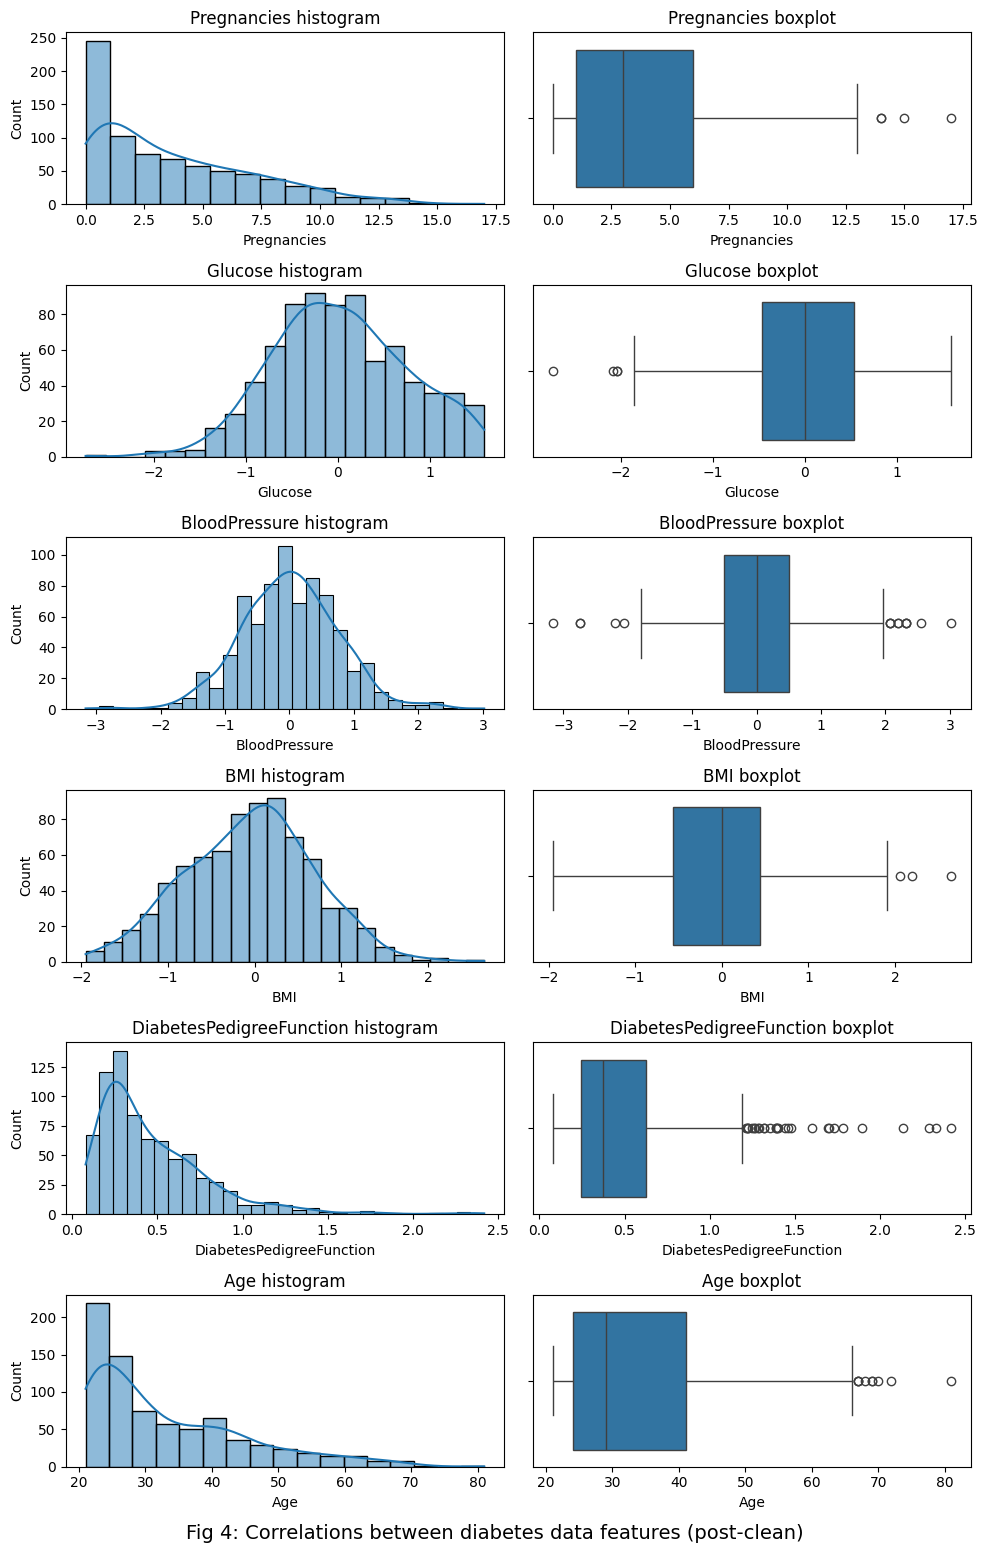

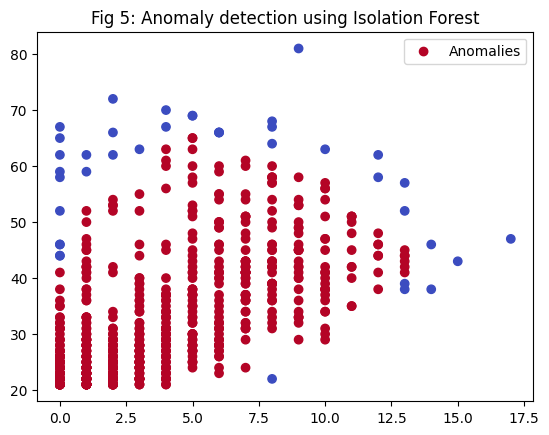

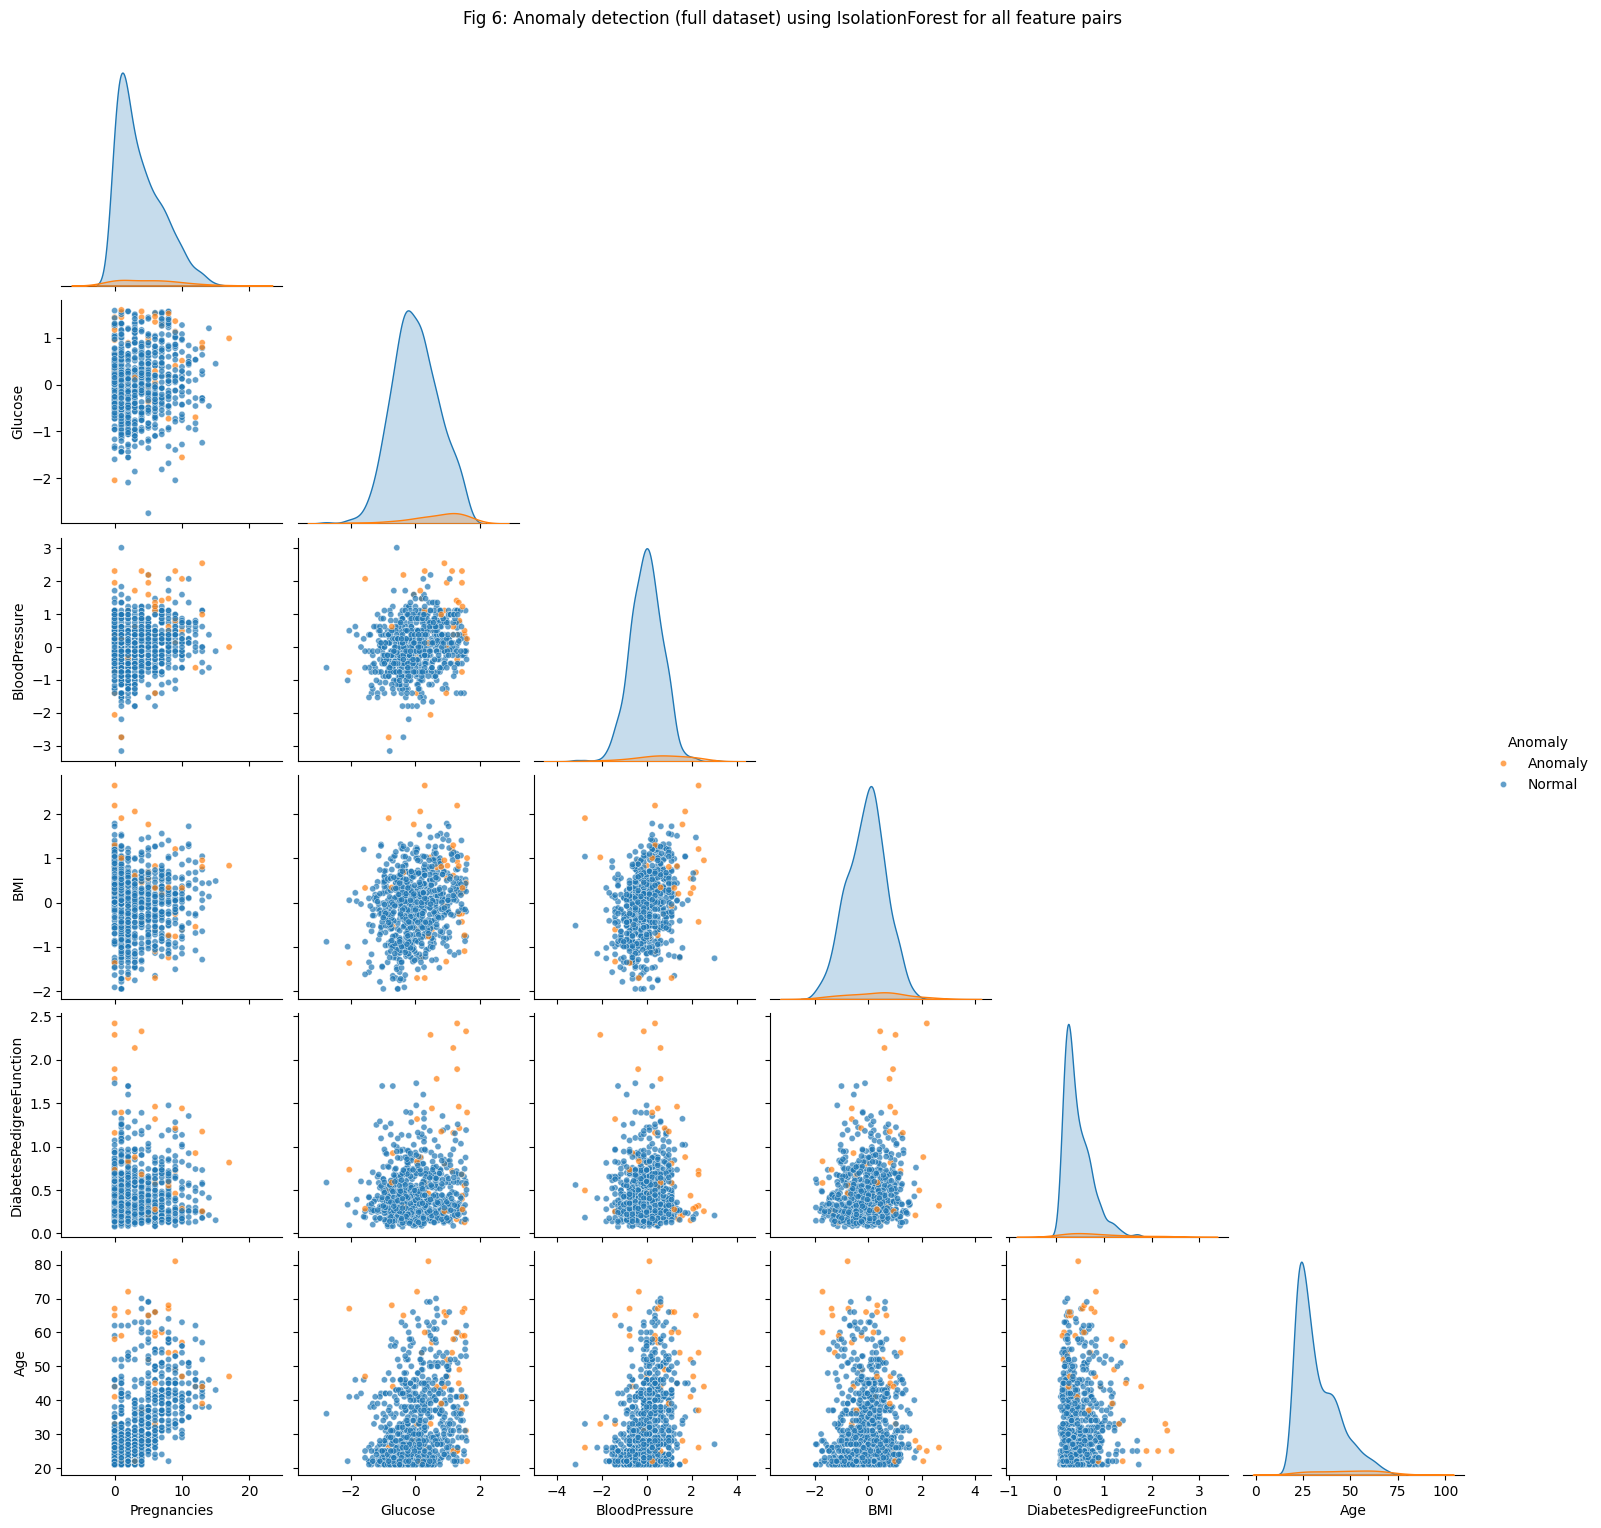

In [ ]:
'''
Note: I have removed Insulin (and Skin Thickness) as a result of our research due to the high
zero count values. See Key Findings for justification
'''
# Copy the data to preserve the original
df= diabdata.drop(columns=['Insulin','SkinThickness']).copy()

# Function to plot Histogram, KDE and Boxplot distributions
def distribution_plot(df, chart_title='Missing title'):
  num_cols = df.columns.drop('Outcome')
  fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))
  for i, c in enumerate(num_cols):
      sns.histplot(df[c], ax=axes[i,0], kde=True)
      axes[i,0].set_title(f'{c} histogram')
      sns.boxplot(x=df[c], ax=axes[i,1])
      axes[i,1].set_title(f'{c} boxplot')
  fig.tight_layout(rect=[0, 0.08, 1, 0.93])
  fig.text(0.5, 0.07, chart_title, ha='center', va='bottom', fontsize=14, wrap=True)
  plt.show()
  print('\n\n\n\n')

# Pre-data clean distribution plots
distribution_plot(df, 'Fig 3: Correlations between diabetes data features (pre-clean)')

# Define columns for which we will set NaN for zero values in features that are medically impossible (Assuming all subjects are alive!)
fill_cols = ['Glucose','BloodPressure','BMI']


# Create a dataframe of only the features we want to impute.
# I tried imputation on the full dataset and it created some extreme values, e.g. insulin
df_impute = df[fill_cols].replace(0, np.nan).copy()

'''**This is here as originally I tried a manual imputation, but then
# decided it would be better to use KNNImputer. I've left it for transparency**'''
# Impute each feature individually with the mean of the feature
#for c in fill_cols:
#  df_impute[c] = df_impute[c].fillna(df_impute[c].mean())

'''
Given the volume of NaN values, and the likely importance of these features,
we should impute the values using KNNImputer. It is important to address outliers
before doing so, as this can skew the imputation outcome with KNNImputer.
'''
imputer = KNNImputer(n_neighbors=5, weights='distance')

'''
Address outliers alongside imputation with PowerTransformer to create a more baysean result 
and RobustScaler which is effective at addressing outliers that we consider rare, genuine cases (not errors).
'''
transformer = Pipeline([
    ('impute', imputer),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scale', RobustScaler())
])
# Perform the transform
np_trans = transformer.fit_transform(df_impute)

# Convert back to a dataframe
df1 = pd.DataFrame(np_trans, columns=df_impute.columns, index=df_impute.index)

# Reconstruct our full dataframe/dataset with transformed features
df[fill_cols]  = df[fill_cols].astype('float64')
df.loc[:, fill_cols] = df1.reindex(df.index)[fill_cols].astype('float64')

# Re-plot our distributions following pre-processing
distribution_plot(df, 'Fig 4: Correlations between diabetes data features (post-clean)')

# Take an in-depth look at anomolies/outliers using IsolationForest for single pair
def iso_single(data, f1='Pregnancies', f2='Age'):
  X = data[[f1,f2]]

  iso_forest = IsolationForest(contamination=0.05, random_state=42)
  labels_if = iso_forest.fit_predict(X)

  plt.scatter(X[f1], X[f2], c=labels_if, cmap='coolwarm', label='Anomalies')
  plt.title('Fig 5: Anomaly detection using Isolation Forest')
  plt.legend()
  plt.show()
  print('\n\n\n\n')

# Compare Pregnancies and Age features
iso_single(df, 'Pregnancies', 'Age')

# Anomaly detection across combined dataset, and plot all pairs
# Inspired by McDonald (2022)
num_cols = df.drop(columns=['Outcome'])
X = df.copy()

# Fit Isolation Forest once on all features excluding Outcome
iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(X)
X_plot = X.copy()
X_plot['Anomaly'] = pd.Categorical(np.where(labels == -1, 'Anomaly', 'Normal'))

# Pairplot all pair combinations coloured by anomaly label
palette = ['#ff7f0e', '#1f77b4']
g = sns.pairplot(X_plot, vars=num_cols, hue='Anomaly', palette=palette, corner=True,
                 plot_kws={'alpha':0.7, 's':20})
g.fig.suptitle('Fig 6: Anomaly detection (full dataset) using IsolationForest for all feature pairs', y=1.02)
plt.show()
print('\n\n\n\n')




Several features contained zero values that were not medically plausible and were therefore treated as missing data. Feature distributions were reviewed to identify skew, outliers, and data quality issues before modelling. This preprocessing step improved the reliability of downstream model training.

## Correlation Analysis and Feature Review


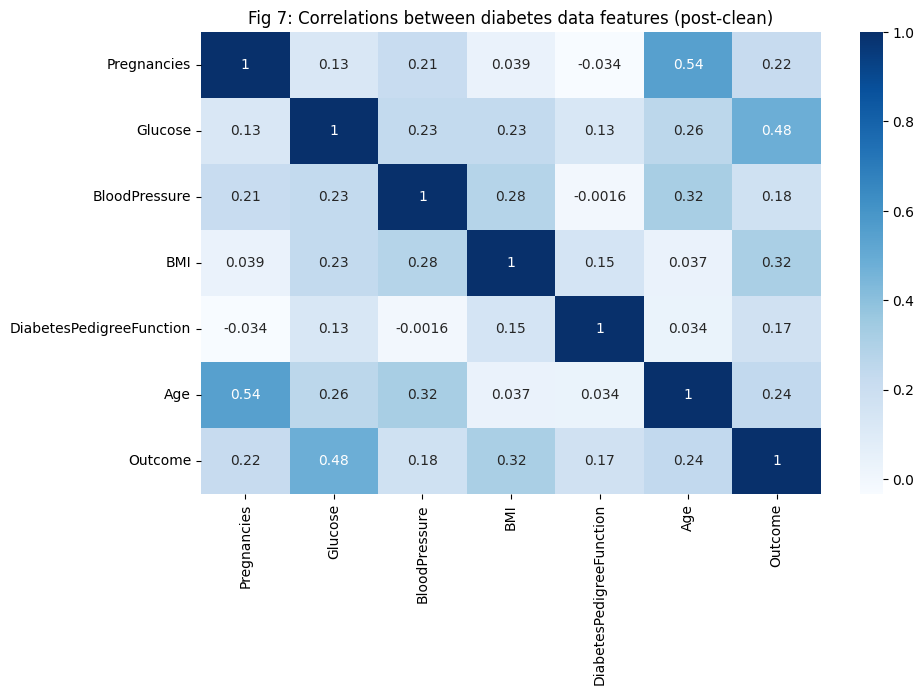

Table 1: VIF values to highlight any multicollinearity (Mukherjee, 2023)
|    | feature                  |     VIF |
|---:|:-------------------------|--------:|
|  0 | Age                      | 5.37744 |
|  1 | Pregnancies              | 3.26141 |
|  2 | DiabetesPedigreeFunction | 2.68228 |
|  3 | BloodPressure            | 1.17888 |
|  4 | BMI                      | 1.16124 |
|  5 | Glucose                  | 1.10907 |






In [ ]:
# Plot correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues')
plt.title('Fig 7: Correlations between diabetes data features (post-clean)')
plt.show()

# Variance Inflation Factor
dfv = df.select_dtypes(include=[np.number]).drop(columns=['Outcome'], errors='ignore')

# Drop any zero-variance columns
dfv = dfv.loc[:, dfv.var() > 0]

# Compute VIFs. Any with values above 10 can likely be dropped
print('Table 1: VIF values to highlight any multicollinearity')
vif = pd.DataFrame({
    'feature': dfv.columns,
    'VIF': [variance_inflation_factor(dfv.values, i) for i in range(dfv.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
print(tabulate(vif,
               headers='keys', tablefmt='pipe'))
print('\n\n\n')


Correlation analysis was used to understand relationships between features after preprocessing. Glucose retained the strongest relationship with the target variable, while some feature pairs showed moderate inter-correlation. These findings informed feature selection and interpretation, but were treated as predictive signals rather than causal relationships.


## Model Development and Comparison


Table 2: Model Scores Sorted by Highest ROC AUC

|    | Model               |   Accuracy % |   Precision |   Recall |   ROC AUC |
|---:|:--------------------|-------------:|------------:|---------:|----------:|
|  0 | Random Forest       |        0.766 |       0.667 |    0.691 |     0.845 |
|  6 | Naive Bayes         |        0.734 |       0.617 |    0.673 |     0.835 |
|  5 | CatBoost            |        0.766 |       0.667 |    0.691 |     0.833 |
|  4 | Logistic Regression |        0.760 |       0.667 |    0.655 |     0.825 |
|  2 | Gradient Boosting   |        0.766 |       0.661 |    0.709 |     0.824 |
|  1 | SVM (RBF)           |        0.721 |       0.636 |    0.509 |     0.766 |
|  3 | kNN                 |        0.695 |       0.577 |    0.545 |     0.753 |
|  7 | Decision Tree       |        0.753 |       0.667 |    0.618 |     0.723 |






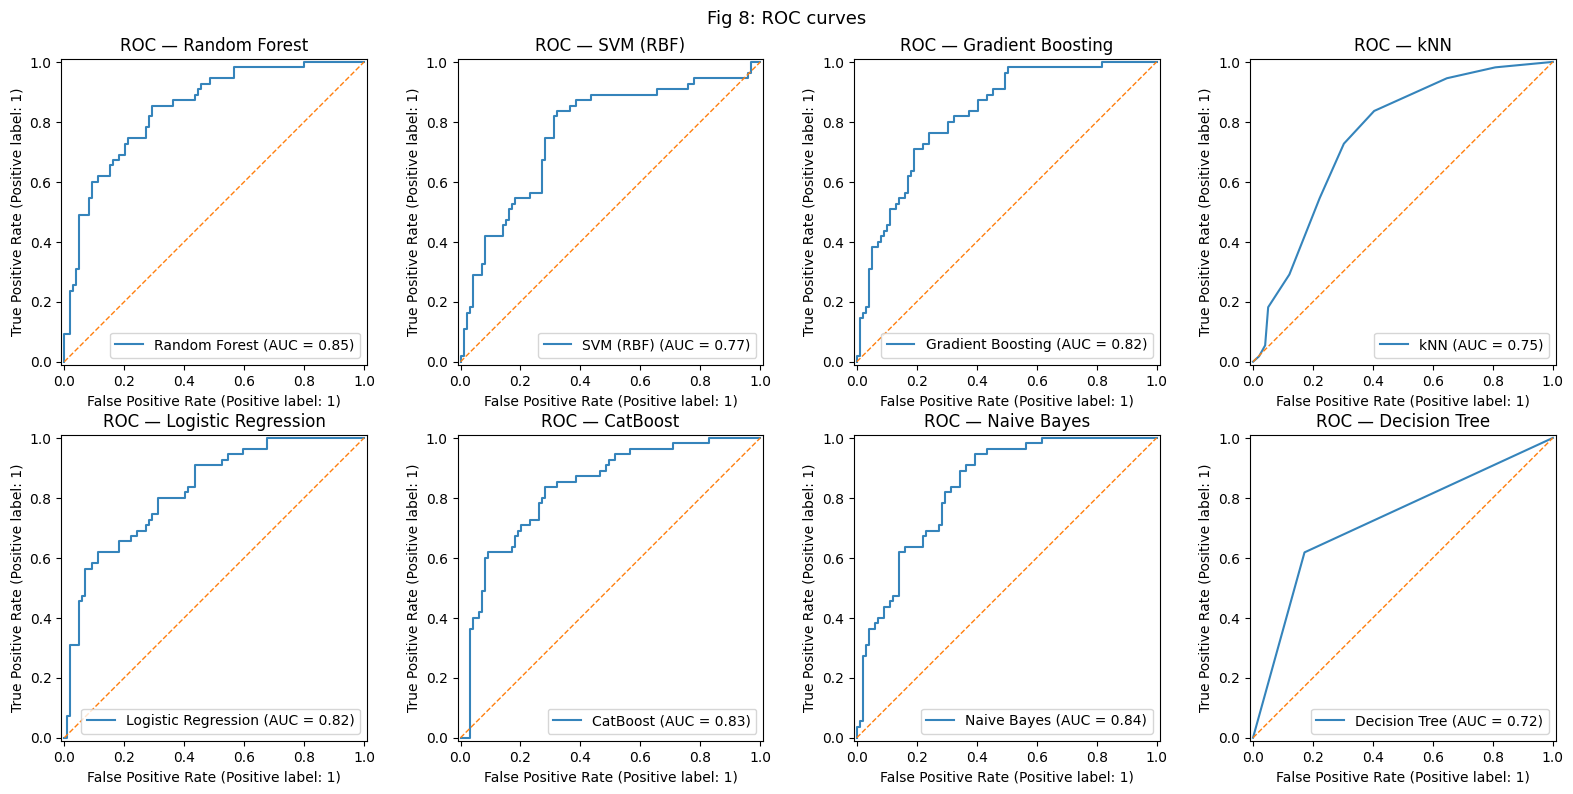

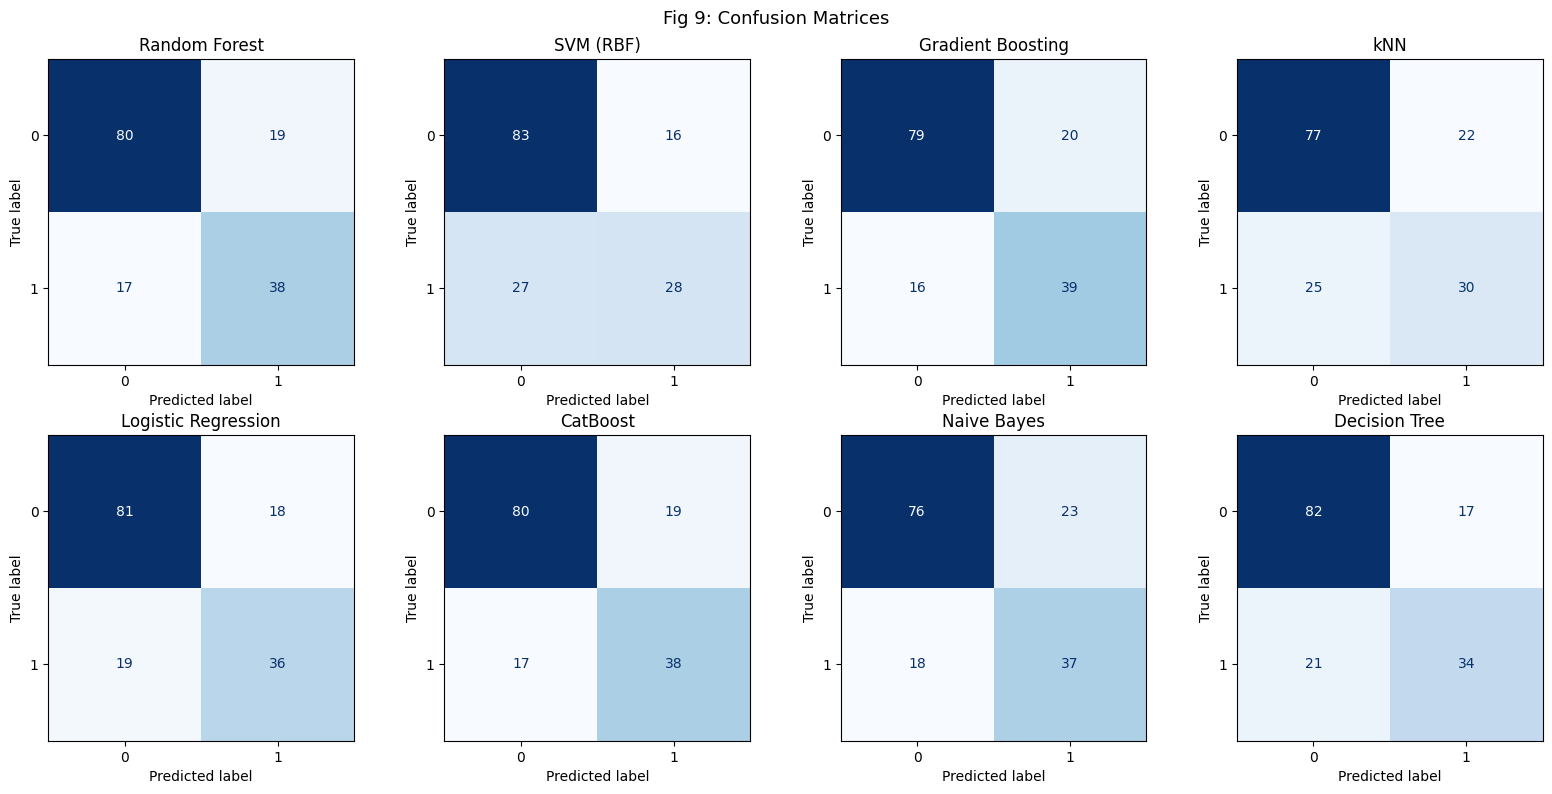

In [ ]:
'''
For this section, I will chose several models to apply to this dataset and measure the performance of each.
This range of models has been sourced from my independent research.

- RandomForest: Ensemble (bagging) of decision trees
- Support Vector Machines (SVM): Margin-based kernel classifier
- Gradient Boosting: Ensemble (boosting) of shallow trees
- k-Nearest Neighbour (kNN): Instance / distance based, non parametric

I will measure the Accuracy, Precision, Recall and ROC AUC scores of each model to compare.

Based on further research, I later added:

- Naive Bayes: Probabilistic generative classifier
- Decision Tree: Tree based classifier (CART)
- Logistic Regression: Regularised logistic regression / Linear model
- CatBoost: Ensemble (gradient boosting) of decision trees. Can be more accurate than GradientBoostingClassifier depending on data

I consider this gives a good range of model types, from basic to more advanced.
'''

# Split our data and target.
X = df.drop(columns='Outcome')
y = df['Outcome']

# Separate our data into test and train; very important to avoid contamination
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''
Here I specify the models and parameters I will use.
Note, various runs were conducted whilst adjusting parameters from the defaults discussed on Scikit-Learn
- Random Forest: Specifying max_depth=10 gave minor improvement
- SVC (RBF): Specifying Gamma='auto' significantly improved scoring
- Gradient Boosting: Increasing max_depth to between 5 and 10 made a significant improvement in accuracy; but could be overfitting
- All other models left with library defaults

If necessary cross-validation can be performed to find the best parameters to optimise ROC AUC
'''
models = {
    'Random Forest': RandomForestClassifier(max_depth=10, random_state=42),
    'SVM (RBF)': SVC(gamma='auto', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(max_depth=5, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=11),
    'Logistic Regression': LogisticRegression(random_state=42),
    'CatBoost': CatBoostClassifier(random_seed=42, logging_level='Silent'),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Create empty results variable
results = []

# Loop through all models, fit, predict and compute all scores appended to results
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)

    # Scores for ROC AUC using decision_function for SVC as this is faster
    if hasattr(clf, 'decision_function'):
        y_scores = clf.decision_function(X_test)
    elif hasattr(clf, 'predict_proba'):
        y_scores = clf.predict_proba(X_test)[:, 1]
    else:
        y_scores = None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec  = recall_score(y_test, y_pred, pos_label=1)
    auc  = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan

    results.append([name, acc, prec, rec, auc])

# Present the results in a table sorted by ROC AUC score
cols = ['Model', 'Accuracy %', 'Precision', 'Recall', 'ROC AUC']
res_df = pd.DataFrame(results, columns=cols).sort_values('ROC AUC', ascending=False)
print('Table 2: Model Scores Sorted by Highest ROC AUC\n')
print(tabulate(res_df, floatfmt='.3f', headers='keys', tablefmt='pipe')) # Ouko (2024)
print('\n\n\n')

# Plot ROC curves for comparison
n = len(models); ncols, nrows = 4, math.ceil(n/4)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.ravel()
for ax, (name, clf) in zip(axes, models.items()):
    clf.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, name=name, alpha=0.9)
    ax.plot([0, 1], [0, 1], '--', linewidth=1)
    ax.set_title(f'ROC — {name}')
for ax in axes[n:]:
    ax.axis('off')
fig.suptitle('Fig 8: ROC curves', y=0.98, fontsize=13)
plt.tight_layout()
plt.show()

print('\n\n\n')

# Create the confusion matrices and display
labels = np.sort(np.unique(y_test))
n = len(models); ncols, nrows = 4, math.ceil(n/4)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.ravel()
for ax, (name, clf) in zip(axes, models.items()):
    clf.fit(X_train, y_train)
    ConfusionMatrixDisplay.from_estimator(
        clf, X_test, y_test,
        display_labels=labels,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name)
for ax in axes[n:]:
    ax.axis('off')
fig.suptitle('Fig 9: Confusion Matrices', y=0.98, fontsize=13)
plt.tight_layout()
plt.show()


Eight classification models were trained and compared using precision, recall, and ROC AUC. ROC AUC was prioritised because it provides a more balanced view of classification performance than accuracy alone, particularly where false positives and false negatives carry different implications.

Tree-based ensemble models (Random Forest and Gradient Boosting) achieved the highest ROC AUC, outperforming linear and single-tree models.

## Final Model Selection


Table 3: Model Scores Sorted by Highest Accuracy

|    | Model               |   Accuracy % |   Precision |   Recall |   ROC AUC |
|---:|:--------------------|-------------:|------------:|---------:|----------:|
|  0 | Random Forest       |        0.766 |       0.667 |    0.691 |     0.845 |
|  2 | Gradient Boosting   |        0.766 |       0.661 |    0.709 |     0.824 |
|  5 | CatBoost            |        0.766 |       0.667 |    0.691 |     0.833 |
|  4 | Logistic Regression |        0.760 |       0.667 |    0.655 |     0.825 |
|  7 | Decision Tree       |        0.753 |       0.667 |    0.618 |     0.723 |
|  6 | Naive Bayes         |        0.734 |       0.617 |    0.673 |     0.835 |
|  1 | SVM (RBF)           |        0.721 |       0.636 |    0.509 |     0.766 |
|  3 | kNN                 |        0.695 |       0.577 |    0.545 |     0.753 |






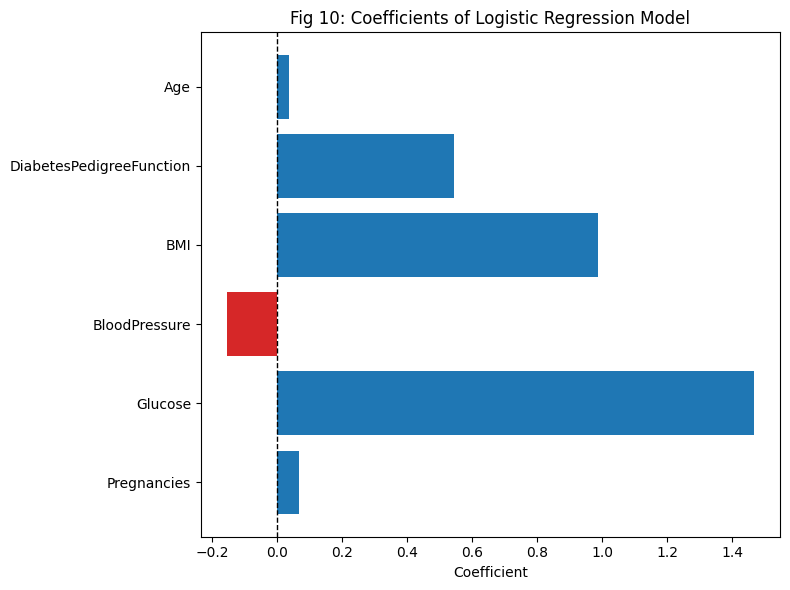

In [ ]:
# Present the model results in a table, this time sorted by Accuracy score
cols = ['Model', 'Accuracy %', 'Precision', 'Recall', 'ROC AUC']
res_df = pd.DataFrame(results, columns=cols).sort_values('Accuracy %', ascending=False)
print('Table 3: Model Scores Sorted by Highest Accuracy\n')
print(tabulate(res_df, floatfmt='.3f', headers='keys', tablefmt='pipe'))
print('\n\n\n')


# Show coefficients
# fit Logistic Regression model as used above during comparison
clf_choice = LogisticRegression(random_state=42).fit(X_train, y_train)
y_pred_choice = clf_choice.predict(X_test)

feat_names = getattr(X_train, 'columns', np.arange(X_train.shape[1]))
coef = pd.Series(clf_choice.coef_.ravel(), index=feat_names)
or_tbl = pd.DataFrame({
    'Feature': coef.index,
    'Coef': coef.values,
    'OR': np.exp(coef.values)
}).sort_values('Coef', key=lambda s: s.abs(), ascending=False)

# Create a bar chart for visual consumption
# Colour the bars according to positive/negative impact
colors = np.where(coef >= 0, 'tab:blue', 'tab:red')
# Plot the histogram
plt.figure(figsize=(8, 6))
plt.barh(coef.index, coef.values, color=colors)
plt.axvline(0, color='k', lw=1, ls='--')
plt.title('Fig 10: Coefficients of Logistic Regression Model')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()


Final model selection considered both predictive performance and interpretability. Ensemble models delivered the strongest predictive performance, while Logistic Regression provided greater transparency. This highlights the trade-off between accuracy and interpretability in real-world applications.

## Local Prediction Explanations

In [ ]:
# Feature and class names
if hasattr(X_test, 'columns'):
    feature_names = X_test.columns.tolist()
else:
    feature_names = [f'feat_{i}' for i in range(X_test.shape[1])]

# Map classes to readable labels, preserving the model class order
class_labels = list(clf_choice.classes_)
name_map = {0: 'Healthy', 1: 'Diabetes'}
target_names = [name_map.get(c, str(c)) for c in class_labels]

# Global explanation (weights)
print('Table 4: Contribution of features in the prediction')
display(show_weights(clf_choice, feature_names=feature_names, target_names=target_names, top=len(feature_names)+1))
print('\n----------------------------------------------------------------------------------------\n')
# pick a test index
idx = np.random.choice(X_test.index)

def show_coef_result(idx, case_desc, case_heading):
  row_df = X_test.loc[[idx]]
  name_map = {0: 'Healthy', 1: 'Diabetes'}
  true_lab = name_map.get(y_test.loc[idx], y_test.loc[idx])
  pred_lab = name_map.get(clf_choice.predict(row_df)[0], clf_choice.predict(row_df)[0])

  print(f'{case_heading} Local Case: {idx} | Actual Target Value: {true_lab} | Model Prediction: {pred_lab}')
  print(f'{case_desc}\n')

  # ELI5 with feature names preserved
  feature_names = row_df.columns.tolist()
  target_names  = [name_map.get(c, str(c)) for c in clf_choice.classes_]
  display(show_prediction(clf_choice, row_df, feature_names=feature_names, target_names=target_names, show_feature_values=True))
  print('\n')

show_coef_result(486, 'False Positive Result', 'Table 5:')
show_coef_result(448, 'False Negative Result', 'Table 6:')
show_coef_result(300, 'Correct Positive Result', 'Table 7:')

Table 4: Contribution of features in the prediction


Weight?,Feature
+1.467,Glucose
+0.988,BMI
+0.545,DiabetesPedigreeFunction
+0.066,Pregnancies
+0.035,Age
-0.153,BloodPressure
-2.578,<BIAS>



----------------------------------------------------------------------------------------

Table 5: Local Case: 486 | Actual Target Value: Healthy | Model Prediction: Diabetes
False Positive Result





Table 6: Local Case: 448 | Actual Target Value: Diabetes | Model Prediction: Healthy
False Negative Result





Table 7: Local Case: 300 | Actual Target Value: Diabetes | Model Prediction: Diabetes
Correct Positive Result



Three representative cases were reviewed to illustrate different prediction outcomes: a correct classification, a false positive, and a false negative. This local analysis helps explain how feature values contributed to individual predictions and provides additional interpretability beyond aggregate model metrics. For example, high glucose levels consistently contributed to positive predictions, reinforcing its role as a dominant feature.

## Fairness Assessment Across Demographic Groups

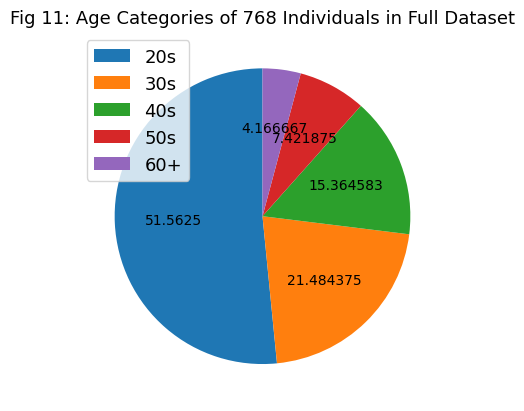

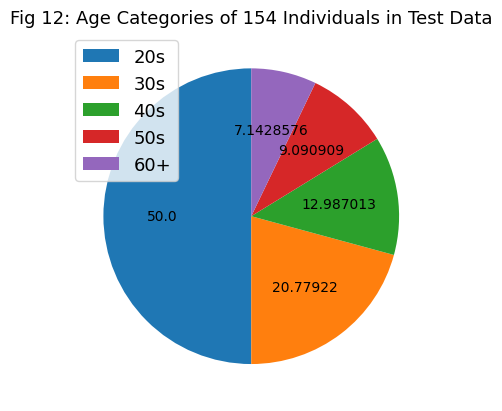


Table 8: Fairness by Age group (Accuracy, False Positive, False Negative)
| AgeGroup   |   n |   Accuracy |   FPR |   FNR |
|:-----------|----:|-----------:|------:|------:|
| 20s        |  77 |      0.805 | 0.085 | 0.556 |
| 30s        |  32 |      0.719 | 0.214 | 0.333 |
| 40s        |  20 |      0.8   | 0.125 | 0.25  |
| 50s        |  14 |      0.786 | 0.333 | 0     |
| 60+        |  11 |      0.455 | 0.667 | 0     |

Gaps (smaller is fairer):
Accuracy Gap          0.351
False Positive Gap    0.582
False Negative Gap    0.556


In [ ]:
# Sensitive attribute chosen: Age

# Function to group age categories for a particular dataset
def age_dist(data, fig_num, data_name):
  # Source original values from the diabdata dataset
  age_raw  = diabdata.loc[data, 'Age']

  # Put into groups/ranges
  age_bins   = [19, 29, 39, 49, 59, np.inf]
  age_labels = ['20s', '30s', '40s', '50s', '60+']
  age_group  = pd.cut(age_raw, bins=age_bins, labels=age_labels, right=True)

  #Plot pie chart for Age groups to see the distribution
  counts_age = age_group.value_counts()
  labels_age = counts_age.index
  plt.pie(counts_age, autopct=str, startangle=90)
  plt.legend(labels_age, loc=2, fontsize=13)
  plt.title(f'{fig_num}: Age Categories of {len(age_group)} Individuals in {data_name}',size=13)
  plt.show()
  return age_group

age_group = age_dist(diabdata.index, 'Fig 11', 'Full Dataset')
age_group = age_dist(y_test.index, 'Fig 12', 'Test Data')


eval_df = pd.DataFrame({'y_true': y_test, 'y_pred_choice': y_pred_choice, 'Age_grp': age_group}, index=y_test.index)

# Per-group Accuracy, False Positive Rate and False Negative Rate
rows = []
for grp, g in eval_df.groupby('Age_grp', dropna=False, observed=True):
    yt, yp = g['y_true'].to_numpy(), g['y_pred_choice'].to_numpy()
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    # Calculate accuracy
    acc = (tp + tn) / (tp + tn + fp + fn)
    # Calculate false positive rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    # Calculate false negative rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    rows.append([str(grp), len(yt), acc, fpr, fnr])

fair_age = pd.DataFrame(rows, columns=['AgeGroup','n','Accuracy','FPR','FNR'])

# Show table and parity gaps
print("\nTable 8: Fairness by Age group (Accuracy, False Positive, False Negative)")
print(tabulate(fair_age.round(3), headers='keys', tablefmt='pipe', showindex=False))

p_gaps = pd.Series({
    'Accuracy Gap': fair_age['Accuracy'].max() - fair_age['Accuracy'].min(),
    'False Positive Gap':      fair_age['FPR'].max() - fair_age['FPR'].min(),
    'False Negative Gap':      fair_age['FNR'].max() - fair_age['FNR'].min(),
})
print("\nGaps (smaller is fairer):")
print(p_gaps.round(3).to_string())


Model performance was reviewed across age and BMI groups to assess whether prediction quality varied between demographic segments. This analysis highlighted differences in error rates between groups, indicating areas where fairness considerations would be important before real-world deployment. These differences indicate potential bias that would need to be addressed before deploying the model in a real-world healthcare context.

## Deployment Considerations and Drift Simulation

Fig 13: Deployment Model for Logistic Regression Service.

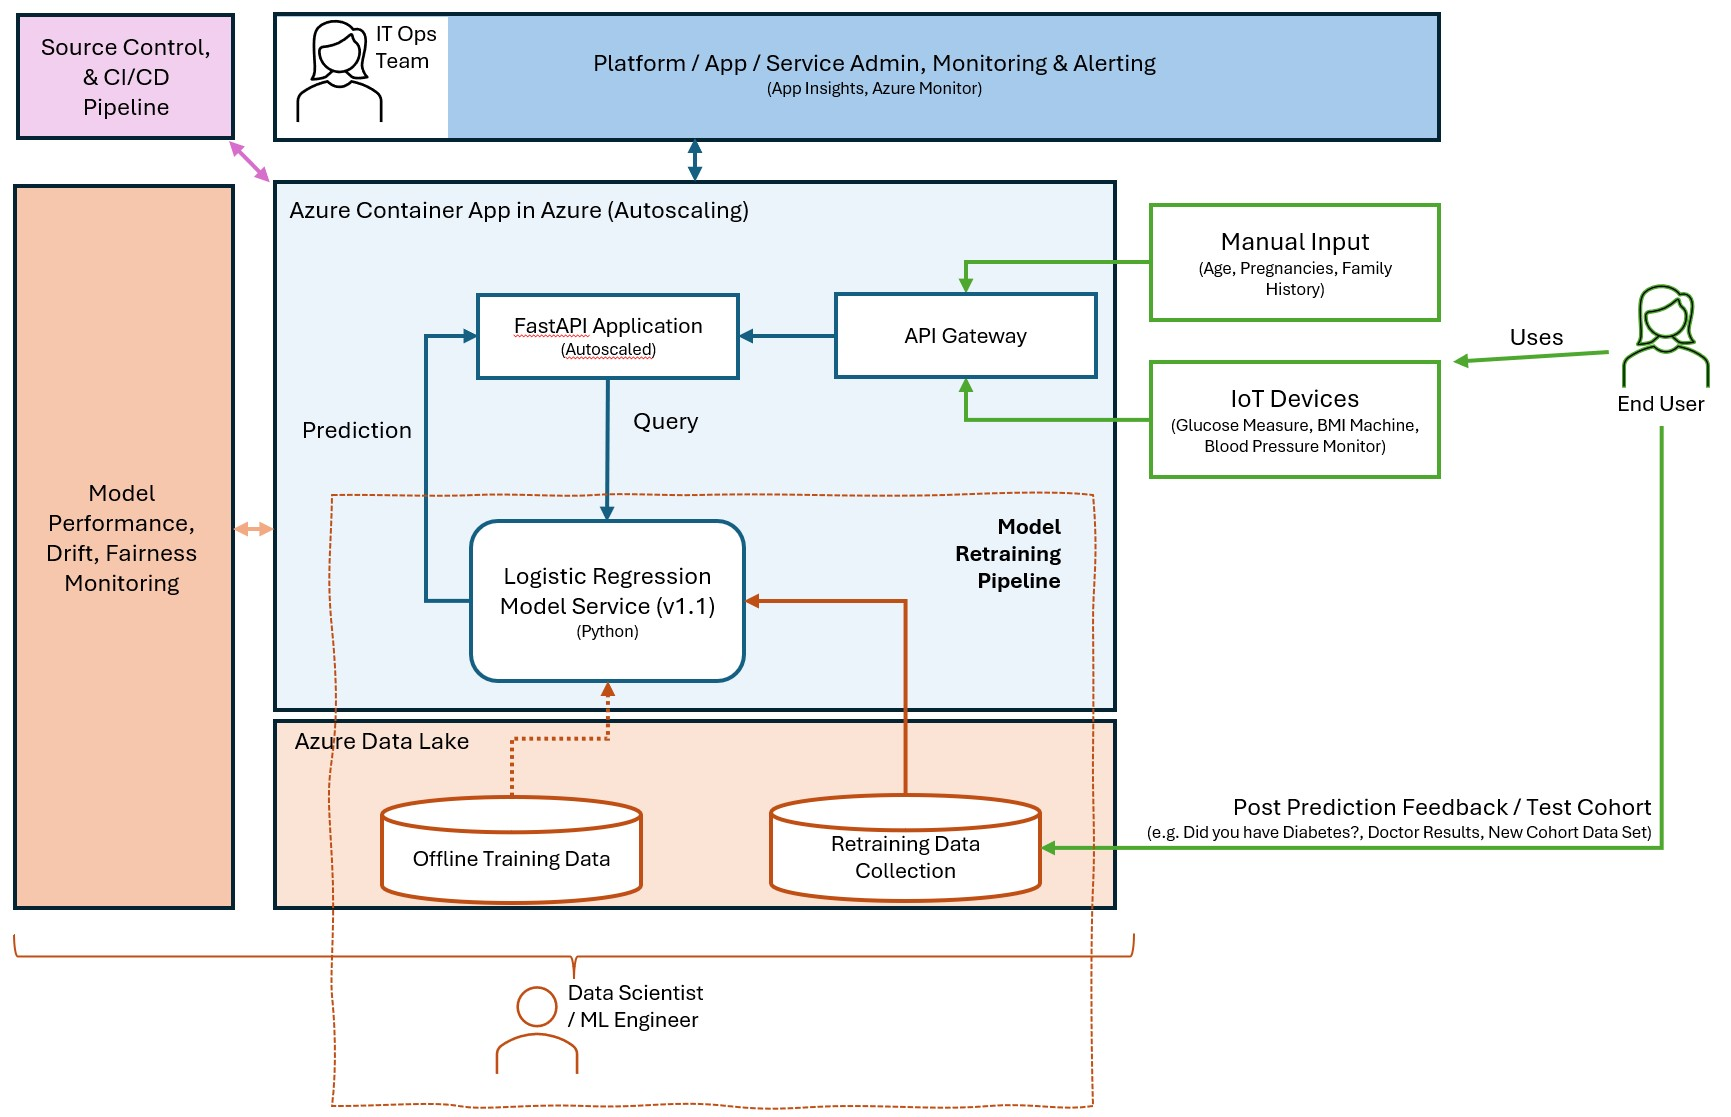

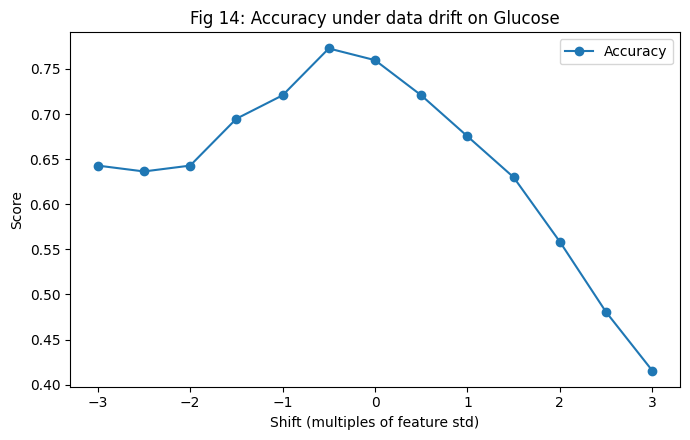

In [ ]:
# Function to simulate data (covariate) drift on a single feature
def drift_sim(clf, X, y, feature, shifts=np.linspace(-3, 3, 13)):
    std = X[feature].std()
    rows = []
    for k in shifts:
        Xd = X.copy()
        Xd[feature] = Xd[feature] + k * std
        scores, thr = clf.predict_proba(Xd)[:, 1], 0.5
        y_pred = (scores >= thr).astype(int)
        rows.append({'shift_std': k,
                     'accuracy': accuracy_score(y, y_pred)
                     })
    return pd.DataFrame(rows)

# Plot the results
def plot_drift(df, xcol, chart_title, xlab):
    plt.figure(figsize=(7, 4.5))
    plt.plot(df[xcol], df['accuracy'], marker='o', label='Accuracy')
    plt.xlabel(xlab); plt.ylabel('Score'); plt.title(chart_title)
    plt.legend(); plt.tight_layout(); plt.show()

# Choose which feature we want to 'drift'
drift_feature = 'Glucose'
dd = drift_sim(clf_choice, X_test, y_test, drift_feature)
plot_drift(dd, 'shift_std',
           f'Fig 14: Accuracy under data drift on {drift_feature}',
           'Shift (multiples of feature std)')


A conceptual deployment design was created to show how the model could be exposed as a prediction service within a production environment. The design includes production considerations such as model serving, version control, input validation, monitoring, and retraining requirements.


Drift simulation was then used to illustrate how shifts in input distributions could affect model performance over time. This demonstrates how shifts in input data can degrade model performance, reinforcing the need for monitoring pipelines in production systems.


## Model Validation, Statistical Testing, and Advanced Modelling

In [ ]:
'''
Hyperparameter Tuning
Using Grid Search CV, which is comprehensive but computationally expensive, I provide a range of hyperparameters to determine which perform best across our Logistic Regression model.
'''

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base_accuracy  = accuracy_score(y_pred_choice, y_test)
print(f'Table 9: The Accuracy of simple logistic regression without hyperparmeters: {base_accuracy:.3f}')

# Set our solvers and hyperparameters. Note, some solvers do not support all 'penalties'
# I've therefore separated out the solvers.
param_grid = [
    # Solvers that only support L2 or no penalty
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2', None],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [1000, 5000],
    },
    # liblinear supports L1 or L2
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [1000, 5000],
    },
    # saga + elasticnet must include l1_ratio
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'l1_ratio': [0.1, 0.5, 0.9],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [1000, 5000],
    },
]

clf_tune = GridSearchCV(LogisticRegression(),param_grid = param_grid, cv=cv, verbose=True,n_jobs=-1)
clf_tune

best_clf = clf_tune.fit(X_train, y_train)
best_clf.best_estimator_

# Show results
print('Best params: ', best_clf.best_params_)
print(f'CV best score: {best_clf.best_score_:.3f}')
print(f'Prediction accuracy: {best_clf.score(X_test,y_test):.3f}')
print('\n\n\n')

'''
To address the point raised on thresholds in the data drift section,
I've created a simply iteration to see which threshold provides the best
accuracy score.
'''
# Set our model to the best parameters found through CV
clf_threshold = LogisticRegression(C=0.08858667904100823, l1_ratio=0.5, max_iter=1000, penalty='elasticnet', solver='saga').fit(X_train, y_train)

# Re-run with a standard 0.5 threshold to ensure same best result
y_pred_threshold = clf_threshold.predict(X_test)
threshold_accuracy = accuracy_score(y_test, y_pred_threshold)
print(f'Table 10: Accuracy of tuned Logistic Regression: {threshold_accuracy:.3f}')

# Set a range of thresholds and pass into the scoring
thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
scores = clf_threshold.predict_proba(X_test)[:, 1]
for t in thresholds:
    y_pred_t = (scores >= t).astype(int)
    acc_t = accuracy_score(y_test, y_pred_t)
    print(f'Accuracy at threshold {t:.1f}: {acc_t:.3f}')
print('\n\n\n')

'''
Finally, I run TabNet and compare the accuracy with LogisticRegression
'''
# Convert df to Numpy as works better with TabNet (GeeksforGeeks, 2025.e)
X_tr = X_train.to_numpy()
y_tr = y_train.to_numpy()
X_te = X_test.to_numpy()
y_te = y_test.to_numpy()

# Instantiate the TabNet classifier.
clf= TabNetClassifier(optimizer_fn=torch.optim.Adam,
                       optimizer_params=dict(lr=1e-3),
                       scheduler_params={'step_size':10, 'gamma':0.9},
                       scheduler_fn=torch.optim.lr_scheduler.StepLR,
                       mask_type='entmax', seed=42)

# fit the model (Note: we get a better result with a batch size of 32 but this takes too long to run for this project)
clf.fit(
    X_tr,y_tr,
    eval_set=[(X_tr, y_tr), (X_te, y_te)],
    eval_name=['train', 'test'],
    eval_metric=['accuracy'],
    max_epochs=200, patience=60,
    batch_size=512, drop_last=False
)

#Make predictions
y_pr=clf.predict(X_te)

# Show the result
print('\n\nTable 11: TabNet Accuracy Result (Untuned hyperparameters)')
print(classification_report(y_te, y_pr))

Table 9: The Accuracy of simple logistic regression without hyperparmeters: 0.760
Fitting 5 folds for each of 440 candidates, totalling 2200 fits
Best params:  {'C': np.float64(0.08858667904100823), 'l1_ratio': 0.9, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}
CV best score: 0.761
Prediction accuracy: 0.779




Table 10: Accuracy of tuned Logistic Regression: 0.779
Accuracy at threshold 0.1: 0.500
Accuracy at threshold 0.2: 0.630
Accuracy at threshold 0.3: 0.708
Accuracy at threshold 0.4: 0.727
Accuracy at threshold 0.5: 0.779
Accuracy at threshold 0.6: 0.779
Accuracy at threshold 0.7: 0.753
Accuracy at threshold 0.8: 0.669
Accuracy at threshold 0.9: 0.643






/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.9049  | train_accuracy: 0.37948 | test_accuracy: 0.36364 |  0:00:00s
epoch 1  | loss: 0.85071 | train_accuracy: 0.36319 | test_accuracy: 0.34416 |  0:00:00s
epoch 2  | loss: 0.82698 | train_accuracy: 0.36645 | test_accuracy: 0.36364 |  0:00:00s
epoch 3  | loss: 0.79215 | train_accuracy: 0.36156 | test_accuracy: 0.35714 |  0:00:00s
epoch 4  | loss: 0.78575 | train_accuracy: 0.36808 | test_accuracy: 0.35714 |  0:00:00s
epoch 5  | loss: 0.78703 | train_accuracy: 0.36319 | test_accuracy: 0.33117 |  0:00:00s
epoch 6  | loss: 0.74055 | train_accuracy: 0.35668 | test_accuracy: 0.31818 |  0:00:01s
epoch 7  | loss: 0.73316 | train_accuracy: 0.35668 | test_accuracy: 0.33766 |  0:00:01s
epoch 8  | loss: 0.70591 | train_accuracy: 0.34528 | test_accuracy: 0.33766 |  0:00:01s
epoch 9  | loss: 0.70367 | train_accuracy: 0.35179 | test_accuracy: 0.37013 |  0:00:01s
epoch 10 | loss: 0.67275 | train_accuracy: 0.37134 | test_accuracy: 0.35714 |  0:00:01s
epoch 11 | loss: 0.67469 | train

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Cross-validation was used to test model stability and tune hyperparameters for Logistic Regression. Statistical testing was then used to assess whether performance differences between models were meaningful.

An additional TabNet model was evaluated to explore deep learning approaches for tabular data, although it did not outperform tree-based methods.

## Conclusion

This project demonstrates an end-to-end machine learning workflow, from data preprocessing through to deployment considerations. 

Ensemble methods achieved the strongest predictive performance, while Logistic Regression provided useful interpretability. The project also considered fairness, local explanations, deployment design, and drift simulation, reflecting the practical requirements of real-world machine learning systems.

### Next Steps
- Validate performance on an external dataset
- Improve model calibration
- Extend fairness analysis across additional demographic dimensions
- Implement monitoring and retraining thresholds for production use